In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

import ladder
plt.close()

In [3]:
pull_predictions_from_weka("consistent_ranking")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_consistent_ranking_predictions.parquet


In [4]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'correct_choice'] # accuracy benchmarks

COLS += ['logits_per_byte', 'logits_per_byte_corr', 'logits_per_char_corr']

df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

Loaded 114,520,000 instance predictions


In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

MMLU  = [t for t in TASKS if 'mmlu' in t]
TASKS = [t for t in TASKS if 'mmlu' not in t and ':para' not in t]
TASKS = sorted(TASKS)

### Running the Model Ladder

In [6]:
ladder_config_path = f'{ROOT_DIR}/olmo-repos/OLMo/scripts/scaling/cheap_decisions.json'
ladder_config_path_no_750m = f'{ROOT_DIR}/olmo-repos/OLMo/scripts/scaling/cheap_decisions_no_750m.json'

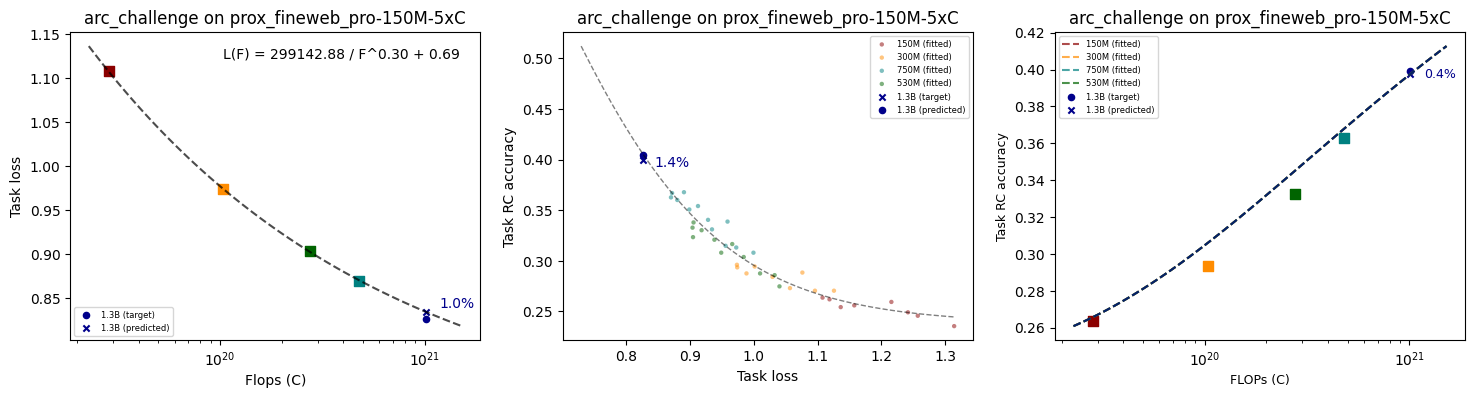

In [7]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]

train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=train_models,
    # eval_models=["peteish7", "peteish13-highlr"],
    # eval_models=["peteish7"],
    eval_models=eval_models,
    config_path=ladder_config_path,
    use_flops=True,
    axes=axes[0],
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

Fitting model ladder predictions:  56%|█████▌    | 5/9 [00:11<00:10,  2.69s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:50: RuntimeWarning: overflow encountered in exp
  return np.exp(p[0]) / x ** p[1] + p[2]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:54: RuntimeWarning: overflow encountered in exp
  grad_a = np.exp(p[0]) / x ** p[1]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:55: RuntimeWarning: overflow encountered in exp
  grad_alpha = np.exp(p[0]) * (-np.log(x)) / x ** p[1]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:416: RuntimeWarning: invalid value encountered in scalar divide
  grad_us = [u if np.abs(u) < delta else (delta * np.abs(u) / u) for u in us]
Fitting model ladder predictions: 100%|██████████| 9/9 [00:18<00:00,  2.03s/it]


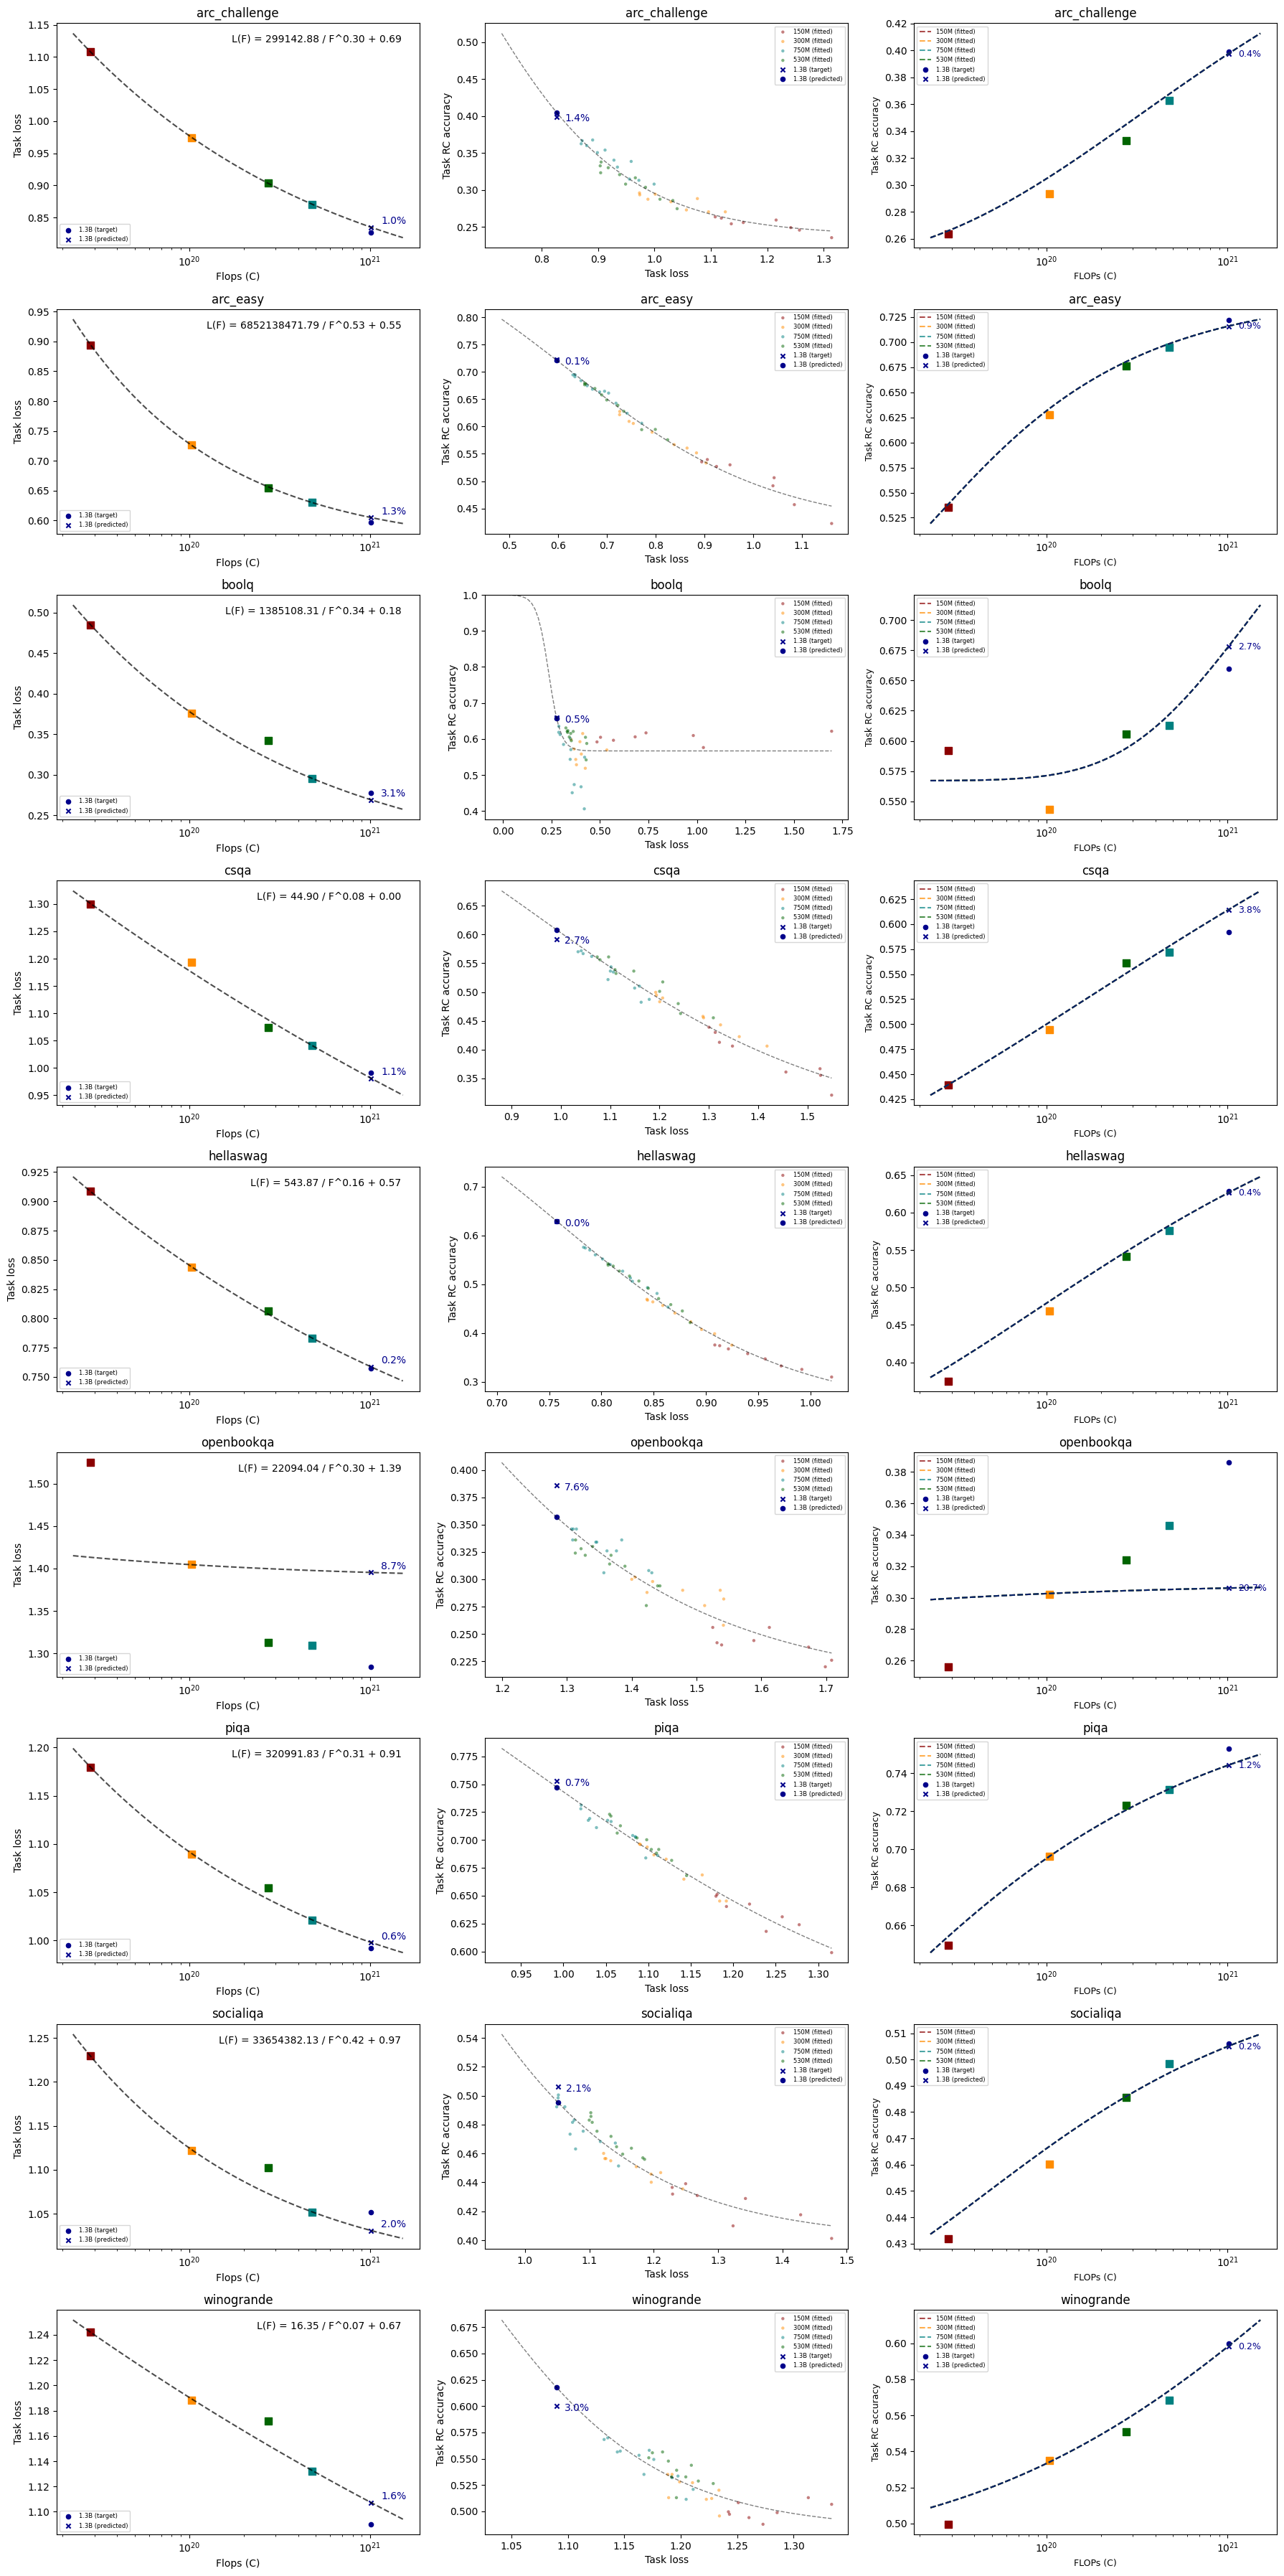

In [15]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    try:
        train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
        _, _, _ = run_ladder(
            df,
            task_name=task,
            train_models=train_models,
            eval_models=eval_models, # ["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            use_flops=True,
            axes=axes[i],
        )
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

### Results on All Mixes

In [9]:
from tqdm import tqdm

fitting_results_step_1 = pd.DataFrame(index=[], columns=TASKS)
fitting_results_step_2 = pd.DataFrame(index=[], columns=TASKS)
stacked_y_preds = pd.DataFrame(index=[], columns=TASKS)

for mix in tqdm(MIXES, desc='Fitting model ladder predictions', total=len(MIXES)):
    models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]

    for i, task in enumerate(TASKS):
        train_models, eval_models = [m for m in models if '1B' not in m], [m for m in models if '1B' in m]
        (rel_error_step_1, rel_error_step_2, _), (step_1_y_pred, step_2_y_pred, stacked_y_pred) = run_ladder(
            df,
            task_name=task,
            train_models=train_models,
            eval_models=eval_models, # ["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            use_flops=True,
            return_preds=True
        )

        fitting_results_step_1.loc[mix, task] = rel_error_step_1
        fitting_results_step_2.loc[mix, task] = rel_error_step_2
        stacked_y_preds.loc[mix, task] = stacked_y_pred

Fitting model ladder predictions:   0%|          | 0/20 [00:00<?, ?it/s]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
Fitting model ladder predictions:   5%|▌         | 1/20 [00:18<05:43, 18.08s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
Fitting model ladder predictions:  25%|██▌       | 5/20 [01:29<04:30, 18.05s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:50: RuntimeWarning: overflow encountered in exp
  return np.exp(p[0]) / x ** p[1] + p[2]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:54: RuntimeWarning: overflow encountered in exp
  grad_a = np.exp(p[0]) / x ** p[1]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/sc

In [10]:
print(f'Relative unsigned error for prediticting 1B-5xC (step 1):')
fitting_results_step_1['avg_error'] = fitting_results_step_1.mean(axis=1)
fitting_results_step_1 = fitting_results_step_1.abs()
fitting_results_step_1 = fitting_results_step_1.sort_values(by='avg_error', ascending=False)
fitting_results_step_1_display = fitting_results_step_1.map(lambda x: f'{round(x*100, 1)}%')
display(fitting_results_step_1_display)

print(f'Relative unsigned error for prediticting 1B-5xC (step 2):')
fitting_results_step_2['avg_error'] = fitting_results_step_2.mean(axis=1)
fitting_results_step_2 = fitting_results_step_2.abs()
fitting_results_step_2 = fitting_results_step_2.sort_values(by='avg_error', ascending=False)
fitting_results_step_2_display = fitting_results_step_2.map(lambda x: f'{round(x*100, 1)}%')
display(fitting_results_step_2_display)

Relative unsigned error for prediticting 1B-5xC (step 1):


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,avg_error
no_reddit,11.8%,17.9%,35.0%,25.3%,0.1%,10.1%,3.2%,18.1%,1.5%,13.3%
no_math_no_code,4.2%,2.8%,30.7%,25.0%,0.3%,6.2%,0.9%,13.5%,0.0%,9.2%
dolma-v1-6-and-sources-baseline,3.9%,8.8%,63.7%,9.3%,0.4%,1.1%,5.0%,8.9%,1.2%,7.1%
dolma17-50p-DCLM-baseline-50p,1.5%,1.5%,41.6%,18.8%,1.0%,2.2%,0.7%,1.8%,1.7%,5.9%
dolma17-75p-DCLM-baseline-25p,3.4%,0.5%,51.9%,6.0%,0.6%,1.3%,0.6%,1.9%,1.1%,5.5%
falcon_and_cc_eli5_oh_top20p,1.0%,6.5%,14.0%,3.5%,0.6%,12.3%,0.2%,2.9%,1.1%,4.7%
falcon_and_cc_tulu_qc_top10,0.2%,0.7%,28.8%,3.0%,0.5%,0.3%,1.5%,4.4%,2.5%,4.6%
baseline,1.5%,2.2%,24.4%,3.1%,0.7%,6.6%,1.2%,11.8%,4.3%,3.6%
redpajama,1.8%,1.2%,33.8%,1.3%,1.7%,0.4%,0.8%,1.8%,1.7%,3.5%
no_flan,2.1%,4.1%,19.9%,5.3%,0.1%,1.8%,1.0%,0.2%,1.1%,3.5%


Relative unsigned error for prediticting 1B-5xC (step 2):


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,avg_error
no_reddit,17.5%,17.9%,3.8%,26.0%,1.3%,17.6%,1.4%,12.9%,1.8%,11.1%
baseline,18.0%,19.2%,12.1%,13.9%,0.3%,17.6%,4.6%,8.4%,0.7%,10.4%
no_math_no_code,16.5%,13.2%,15.6%,6.2%,0.6%,20.7%,0.0%,2.0%,1.2%,6.7%
redpajama,1.6%,3.1%,2.0%,4.3%,0.3%,3.7%,0.3%,0.5%,57.7%,6.3%
falcon_and_cc_og_eli5_oh_top10p,0.8%,0.3%,47.0%,1.3%,1.4%,0.5%,0.3%,1.3%,8.2%,6.2%
no_code,14.0%,6.9%,5.5%,19.0%,0.4%,6.6%,0.3%,9.8%,4.9%,5.9%
dolma-v1-6-and-sources-baseline,3.2%,2.3%,13.9%,17.2%,0.1%,0.7%,0.9%,11.3%,5.2%,4.8%
falcon_and_cc,3.4%,0.7%,5.1%,1.4%,0.0%,5.0%,1.0%,4.2%,18.7%,3.0%
dolma17-75p-DCLM-baseline-25p,3.1%,0.1%,12.3%,11.8%,0.2%,2.4%,0.4%,1.8%,3.1%,2.6%
dolma17-50p-DCLM-baseline-50p,6.5%,3.1%,10.9%,12.4%,0.8%,6.1%,0.2%,1.5%,0.3%,2.4%


In [11]:
print('Predicted performance for 1B-5xC on all mixes:')
stacked_y_preds['macro_avg'] = stacked_y_preds.mean(axis=1)
stacked_y_preds = stacked_y_preds.sort_values(by='macro_avg', ascending=False)
stacked_y_preds_display = stacked_y_preds.map(lambda x: f'{round(x * 100, 1)}%')
stacked_y_preds_display

Predicted performance for 1B-5xC on all mixes:


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,macro_avg
falcon_and_cc_og_eli5_oh_top10p,40.5%,71.9%,99.3%,66.1%,63.5%,37.5%,73.4%,51.9%,60.7%,62.8%
falcon_and_cc_eli5_oh_top10p,41.1%,73.7%,64.6%,62.1%,63.5%,37.0%,74.7%,51.2%,60.2%,58.7%
dolma17-25p-DCLM-baseline-75p,39.8%,70.2%,59.5%,62.9%,60.9%,35.8%,73.9%,53.4%,63.6%,57.8%
fineweb_edu_dedup,41.9%,75.7%,63.3%,59.9%,58.8%,35.5%,74.1%,50.0%,60.0%,57.7%
prox_fineweb_pro,39.8%,71.6%,67.8%,61.4%,62.6%,30.6%,74.4%,50.5%,59.8%,57.6%
DCLM-baseline,39.7%,71.7%,62.4%,64.5%,61.8%,36.4%,74.5%,50.8%,56.7%,57.6%
falcon_and_cc_eli5_oh_top20p,38.8%,70.5%,62.1%,61.5%,63.0%,30.1%,74.5%,50.6%,61.0%,56.9%
falcon_and_cc_tulu_qc_top10,38.9%,72.0%,59.1%,62.9%,59.3%,37.4%,73.5%,49.4%,57.6%,56.7%
dolma17-50p-DCLM-baseline-50p,37.9%,72.2%,56.3%,64.0%,60.1%,34.7%,75.0%,50.4%,58.6%,56.6%
falcon_and_cc,33.3%,66.4%,61.4%,61.0%,60.3%,33.9%,73.5%,51.0%,58.6%,55.5%


### Predict without 750M point

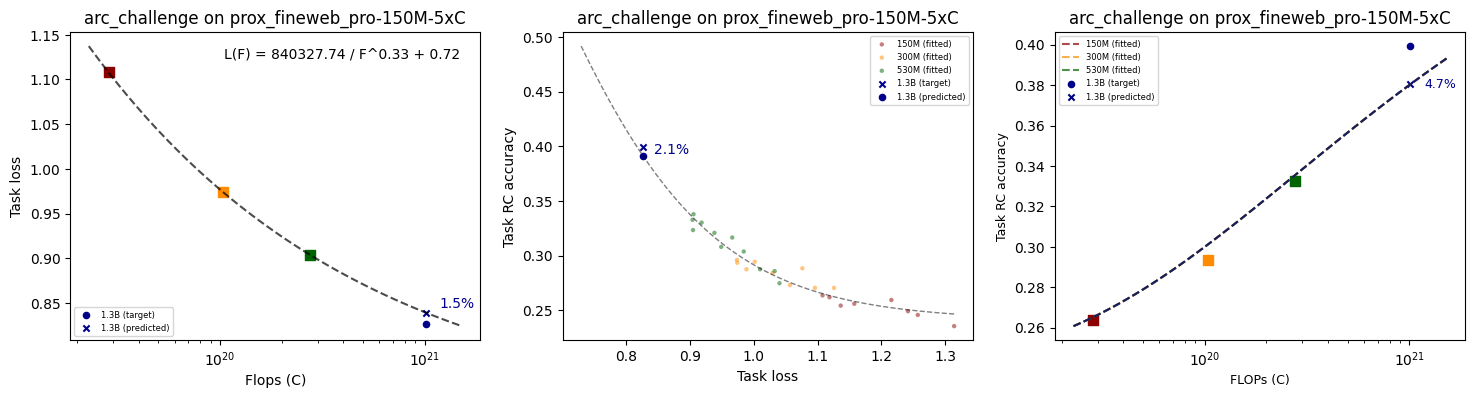

In [12]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]

train_models, eval_models = [m for m in example_models if '1B' not in m and '750M' not in m], [m for m in example_models if '1B' in m]
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=train_models,
    eval_models=eval_models,
    config_path=ladder_config_path_no_750m,
    use_flops=True,
    axes=axes[0]
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

In [13]:
from tqdm import tqdm

fitting_results_step_1_no_750m = pd.DataFrame(index=[], columns=TASKS)
fitting_results_step_2_no_750m = pd.DataFrame(index=[], columns=TASKS)
stacked_y_preds_no_750m = pd.DataFrame(index=[], columns=TASKS)

for mix in tqdm(MIXES, desc='Fitting model ladder predictions', total=len(MIXES)):
    models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]

    for i, task in enumerate(TASKS):
        train_models, eval_models = [m for m in models if '1B' not in m and '750M' not in m], [m for m in models if '1B' in m]
        (rel_error_step_1, rel_error_step_2, _), (step_1_y_pred, step_2_y_pred, stacked_y_pred) = run_ladder(
            df,
            task_name=task,
            train_models=train_models,
            eval_models=eval_models,
            config_path=ladder_config_path_no_750m,
            use_flops=True,
            return_preds=True
        )

        fitting_results_step_1_no_750m.loc[mix, task] = rel_error_step_1
        fitting_results_step_2_no_750m.loc[mix, task] = rel_error_step_2
        stacked_y_preds_no_750m.loc[mix, task] = stacked_y_pred

Fitting model ladder predictions:  50%|█████     | 10/20 [02:22<02:22, 14.21s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:50: RuntimeWarning: overflow encountered in exp
  return np.exp(p[0]) / x ** p[1] + p[2]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:54: RuntimeWarning: overflow encountered in exp
  grad_a = np.exp(p[0]) / x ** p[1]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:55: RuntimeWarning: overflow encountered in exp
  grad_alpha = np.exp(p[0]) * (-np.log(x)) / x ** p[1]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:416: RuntimeWarning: invalid value encountered in scalar divide
  grad_us = [u if np.abs(u) < delta else (delta * np.abs(u) / u) for u in us]
Fitting model ladder predictions:  65%|██████▌   | 13/20 [03:04<01:39, 14.27s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_l

In [17]:
print('Predicted performance for 1B-5xC (without using 750M) on all mixes:')
stacked_y_preds_no_750m['macro_avg'] = stacked_y_preds_no_750m.mean(axis=1)
stacked_y_preds_no_750m = stacked_y_preds_no_750m.sort_values(by='macro_avg', ascending=False)
stacked_y_preds_no_750m_display = stacked_y_preds_no_750m.map(lambda x: f'{round(x * 100, 1)}%')
stacked_y_preds_no_750m_display

Predicted performance for 1B-5xC (without using 750M) on all mixes:


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,macro_avg
no_reddit,61.1%,76.3%,57.2%,62.5%,59.6%,99.9%,76.4%,43.0%,56.5%,65.8%
DCLM-baseline,43.2%,74.6%,83.7%,65.2%,60.6%,33.9%,74.8%,50.8%,58.8%,60.6%
falcon_and_cc_eli5_oh_top20p,40.9%,73.4%,63.2%,68.0%,62.6%,40.5%,75.7%,55.0%,61.5%,60.1%
falcon_and_cc_og_eli5_oh_top10p,43.5%,71.5%,58.0%,67.1%,63.1%,35.3%,74.6%,52.5%,69.1%,59.4%
dolma17-25p-DCLM-baseline-75p,41.3%,72.9%,61.8%,62.2%,63.6%,34.2%,74.4%,54.1%,63.5%,58.7%
falcon_and_cc_eli5_oh_top10p,40.0%,73.6%,57.1%,67.0%,65.4%,34.6%,74.1%,51.2%,56.7%,57.7%
prox_fineweb_pro,38.0%,71.9%,64.2%,64.3%,61.7%,39.8%,73.6%,48.4%,57.0%,57.7%
dolma17-50p-DCLM-baseline-50p,38.0%,69.8%,56.3%,69.1%,60.7%,34.5%,76.3%,49.0%,60.3%,57.1%
falcon_and_cc_tulu_qc_top10,35.7%,72.3%,58.6%,64.8%,59.8%,33.8%,74.1%,52.4%,61.8%,57.0%
fineweb_edu_dedup,42.7%,74.4%,58.1%,62.6%,58.3%,37.3%,72.8%,50.9%,56.2%,57.0%


### Export Data

In [18]:
# Export predictions of 1B performance with/without 750M data-point
stacked_y_preds.to_csv(f'{DATA_DIR}/cheap_decisions_stacked_rc_pred.csv')
stacked_y_preds_no_750m.to_csv(f'{DATA_DIR}/cheap_decisions_stacked_rc_pred_no_750m.csv')